# Reproject, resample & align

Three ways to change a raster's grid:

- **`to_crs(epsg)`** — reproject to another coordinate reference system.
- **`resample(cell_size)`** — change the pixel size (resolution) within the same CRS.
- **`align(reference)`** — snap rows/columns/cell-size/CRS to match another raster. This is
  the operation you use to make every layer line up with a DEM before modelling.

## Setup

In [1]:
%matplotlib inline

import tempfile
from pathlib import Path

DATA = Path('../../../examples/data')
WORK = Path(tempfile.mkdtemp(prefix='pyramids-ops-'))
DATA.is_dir(), WORK.is_dir()

(True, True)

In [2]:
from pyramids.dataset import Dataset

ds = Dataset.read_file(DATA / 'acc4000.tif')
ds.shape, ds.epsg, ds.cell_size

((1, 13, 14), 32618, 4000.0)

The input raster on its native UTM grid — compare each transformed result below against it.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


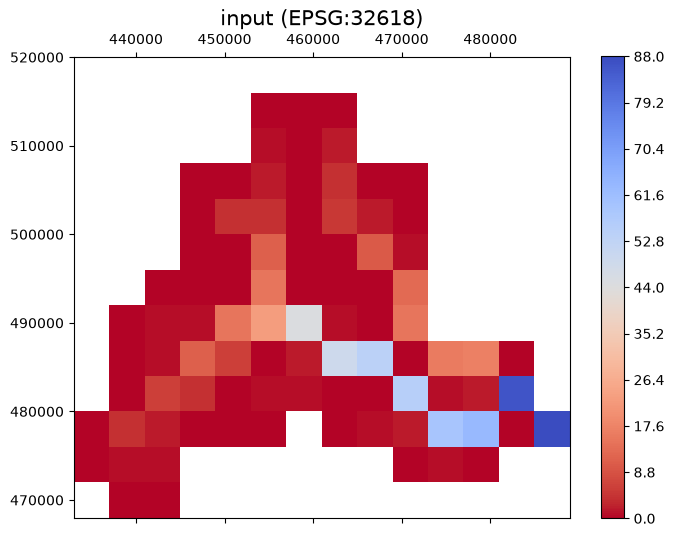

In [3]:
ds.plot(band=0, title="input (EPSG:32618)")

## Reproject — `to_crs`

Reproject from UTM (EPSG:32618) to geographic lon/lat (EPSG:4326).

In [4]:
wgs84 = ds.to_crs(4326)
wgs84.epsg, wgs84.shape, wgs84.cell_size

(4326, (1, 13, 14), 0.03611587177268461)

Reprojected to lon/lat — same scene, but the axes are now degrees instead of metres.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


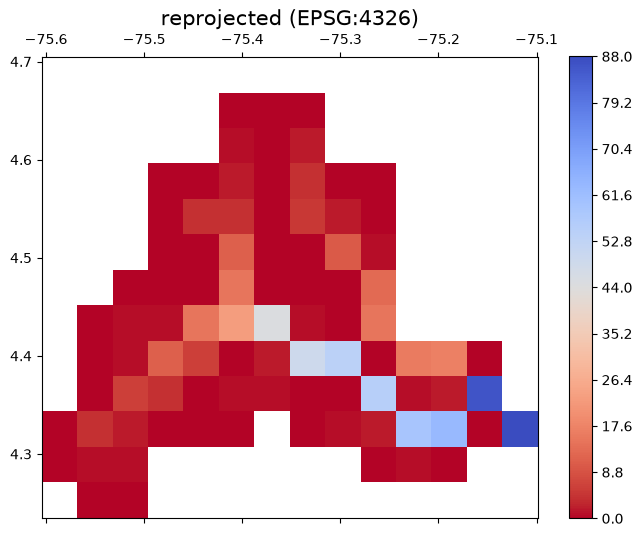

In [5]:
wgs84.plot(band=0, title="reprojected (EPSG:4326)")

## Resample — `resample`

Double the cell size; the row/column count roughly halves.

In [6]:
coarser = ds.resample(cell_size=ds.cell_size * 2)
coarser.cell_size, coarser.shape

(8000.0, (1, 6, 7))

Resampled to double the cell size — the same extent rendered on a coarser grid with blockier pixels.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


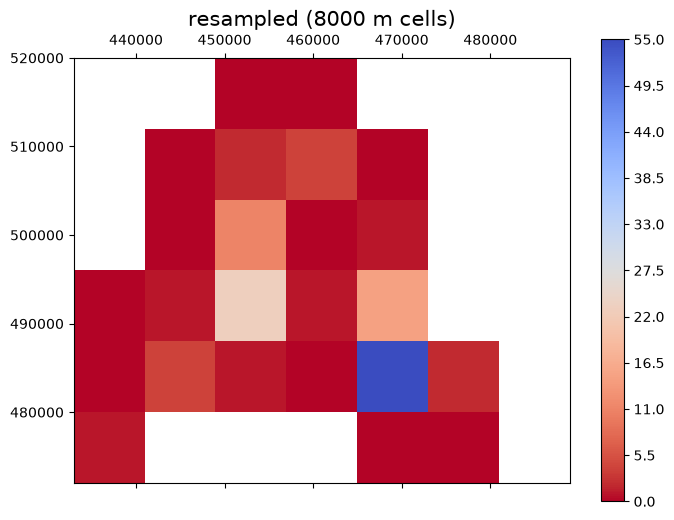

In [7]:
coarser.plot(band=0, title="resampled (8000 m cells)")

## Align to a reference — `align`

`align` copies the reference raster's grid (rows, columns, cell size, CRS) onto the data, so
the two share an identical geotransform — the prerequisite for cell-by-cell raster algebra.

In [8]:
reference = ds.resample(cell_size=ds.cell_size * 2)  # stand-in reference grid
aligned = ds.align(reference)
aligned.shape == reference.shape, aligned.cell_size == reference.cell_size

(True, True)

The aligned raster now shares the reference grid exactly, so it lines up cell-for-cell for raster algebra.

/home/runner/work/pyramids/pyramids/.pixi/envs/docs/lib/python3.14/site-packages/matplotlib/colors.py:824: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


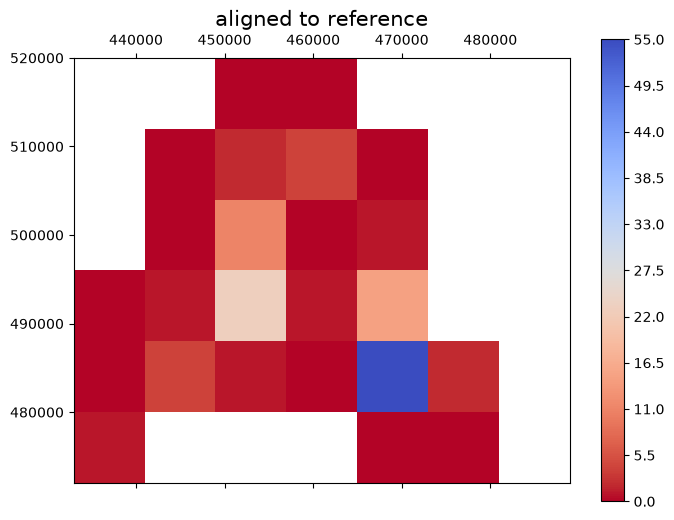

In [9]:
aligned.plot(band=0, title="aligned to reference")

## Notes

- `to_crs` / `resample` take a `method=` (`"nearest neighbor"`, `"bilinear"`, `"cubic"`);
  use nearest for categorical data, bilinear/cubic for continuous.
- See also: [Crop & mask](crop-mask.ipynb), [Mosaic / merge](mosaic-merge.ipynb).